# Component: Thermosteric / Ocean Thermal Expansion

This notebook calibrates, validates, and projects the thermosteric (ocean thermal expansion) component of GMSL rise. Three model variants are compared:
- **Stage 1**: Quadratic DOLS in level-space (rate = a·T² + b·T + c)
- **Stage 1b (1-layer)**: Single-layer physical ODE with ocean state variable S_u and relaxation time τ_u
- **Stage 1b (2-layer)**: Two-layer extension with deep ocean relaxation τ_d

The physical model (1-layer) is used for projections.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-poster')

# Local modules
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
sys.path.insert(0, '.')
from slr_data_readers import read_berkeley_earth, read_noaa_thermosteric
from bayesian_dols import (
    build_level_design_vectors, fit_bayesian_level,
    calibrate_exponential_prior, fit_bayesian_thermosteric,
    solve_twolayer_ode, check_convergence,
)
from slr_projections import project_thermosteric_ensemble
from component_analysis import model_ensemble_draws
from component_projections import (
    read_ipcc_component_nc, ipcc_extract, get_our_stats, get_ipcc_stats,
)
from component_plotting import (
    SSP_COLORS, COMP_COLORS, M_TO_MM,
    plot_component_projection_twopanel,
    plot_component_histogram,
    plot_component_ridge,
)

# Paths
H5_PATH = '../data/processed/slr_processed_data.h5'
RAW_DIR = '../data/raw'
FIG_DIR = '../figures'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

# Constants
BASELINE_YEAR = 2005.0
N_SAMPLES = 2000
M_TO_MM = 1000.0

## 1. Data Loading

**Primary observations**: NOAA thermosteric SL (0–700 m, 1955–2025) — direct in situ measurements.

**Joint calibration**: EN4 global subsurface T (0–700 m, 1970–2021) — constrains ocean thermal lag τ_u and provides transfer function S_u → T_subsurface for Greenland discharge coupling.

**Validation only**: Frederikse et al. (2020) steric component — used for Stage 1 DOLS comparison; pre-1955 is model-constrained, not pure observations.

In [2]:
# ── Berkeley Earth monthly temperature ──
df_temp = pd.read_hdf(H5_PATH, key='harmonized/df_berkeley_h')
temp_monthly = df_temp['temperature'].values
# Convert datetime index to decimal year
temp_time_monthly = (df_temp.index.year
                     + (df_temp.index.month - 0.5) / 12.0).values

# Annual temperature (for diagnostics)
yr_int = np.floor(temp_time_monthly).astype(int)
unique_yrs = np.unique(yr_int)
T_annual = np.array([temp_monthly[yr_int == y].mean() for y in unique_yrs])
T_annual_years = unique_yrs + 0.5

# ── NOAA thermosteric SL (0–700 m, yearly, 1955–2025) — PRIMARY ──
NOAA_TSL_H5_KEY = 'harmonized/df_noaa_tsl_0_700m'
try:
    df_noaa_tsl = pd.read_hdf(H5_PATH, NOAA_TSL_H5_KEY)
except KeyError:
    from slr_forecast.readers.forcing import read_noaa_thermosteric_yearly
    df_noaa_tsl = read_noaa_thermosteric_yearly(
        f'{RAW_DIR}/steric/noaa_tsl_yearly_0-700m.dat')
    df_noaa_tsl.to_hdf(H5_PATH, NOAA_TSL_H5_KEY, mode='a')

noaa_year = df_noaa_tsl['decimal_year'].values
noaa_tsl_mm = df_noaa_tsl['tsl_mm'].values
noaa_tsl_se_mm = df_noaa_tsl['tsl_se_mm'].values

# Rebaseline to 1995–2005 and convert mm → m
bl_mask = (noaa_year >= 1995.0) & (noaa_year <= 2006.0)
noaa_tsl_m = (noaa_tsl_mm - noaa_tsl_mm[bl_mask].mean()) / M_TO_MM
noaa_tsl_se_m = noaa_tsl_se_mm / M_TO_MM

print(f'NOAA thermosteric SL (0–700 m): {noaa_year[0]:.0f}–{noaa_year[-1]:.0f} '
      f'({len(noaa_year)} pts)')
print(f'  Range: [{noaa_tsl_m.min()*M_TO_MM:.1f}, {noaa_tsl_m.max()*M_TO_MM:.1f}] mm '
      f'(rebased to 1995–2005)')

# ── EN4 global subsurface T (0–700 m, monthly, 1970–2021) — JOINT CALIBRATION ──
EN4_GLOBAL_H5_KEY = 'harmonized/df_en4_global_0_700m'
try:
    df_en4_global = pd.read_hdf(H5_PATH, EN4_GLOBAL_H5_KEY)
except KeyError:
    from slr_forecast.readers.ocean_temp import read_en4_regional
    df_en4_global = read_en4_regional(
        f'{RAW_DIR}/ocean_temp/en4/',
        lat_bounds=(-90.0, 90.0),
        lon_bounds=(-180.0, 180.0),
        depth_bounds=(0.0, 700.0),
    )
    df_en4_global.to_hdf(H5_PATH, EN4_GLOBAL_H5_KEY, mode='a')

en4_global_time = df_en4_global['decimal_year'].values
en4_global_temp = df_en4_global['temperature'].values  # anomaly, °C
en4_global_sigma = df_en4_global['temperature_sigma'].values

print(f'EN4 global subsurface T (0–700 m): {en4_global_time[0]:.1f}–'
      f'{en4_global_time[-1]:.1f} ({len(en4_global_temp)} months)')

# ── Frederikse thermosteric (for Stage 1 comparison/validation only) ──
df_fred = pd.read_hdf(H5_PATH, key='derived/df_frederikse_thermo')
fred_year = df_fred['year'].values + 0.5  # mid-year decimal
fred_steric = df_fred['steric'].values
fred_steric_sigma = df_fred['steric_sigma'].values

bl_idx_fred = np.argmin(np.abs(fred_year - BASELINE_YEAR))
steric_rebase = fred_steric - fred_steric[bl_idx_fred]

print(f'Frederikse steric (validation): {fred_year[0]:.0f}–{fred_year[-1]:.0f}, '
      f'{len(fred_year)} points')

NOAA thermosteric SL (0–700 m): 1956–2026 (71 pts)
  Range: [-15.9, 23.9] mm (rebased to 1995–2005)
EN4 global subsurface T (0–700 m): 1970.0–2021.5 (618 months)
Frederikse steric (validation): 1900–2018, 119 points


In [ ]:
# ══════════════════════════════════════════════════════════════════
# REFIT SWITCH — set False to skip fitting and load saved results.
# If loading fails (no HDF5 file), fitting runs automatically.
# ══════════════════════════════════════════════════════════════════
REFIT = True

from component_io import save_ocean, load_component

if not REFIT:
    try:
        _loaded = load_component('ocean')
        thermo_proj = _loaded['projections']
        PROJ_YEARS = _loaded['proj_years']
        ocean_transfer = _loaded.get('ocean_transfer', {})
        print(f'Loaded ocean from HDF5: {list(thermo_proj.keys())}')
        if ocean_transfer:
            print(f'  Transfer function: kappa={ocean_transfer.get("kappa", "?"):.3f}, '
                  f'delta={ocean_transfer.get("delta", "?"):.4f}')
    except (FileNotFoundError, KeyError) as e:
        print(f'Load failed ({e}) — falling back to REFIT=True')
        REFIT = True

## 2. Model Fitting

### 2a. Stage 1 — Quadratic DOLS (level-space)

In [3]:
if REFIT:
    # ── Build design vectors ──
    design_thermo = build_level_design_vectors(
        temperature_monthly=temp_monthly,
        time_monthly=temp_time_monthly,
        obs_times=fred_year,
    )

    # ── Priors ──
    PRIOR_SCALE_A_THERMO = calibrate_exponential_prior(
        prob_exceed=0.10, threshold=0.10 / M_TO_MM)
    PRIOR_SCALE_B_THERMO = calibrate_exponential_prior(
        prob_exceed=0.10, threshold=0.20 / M_TO_MM)
    PRIOR_C_MEAN_THERMO = 0.0003
    PRIOR_C_SIGMA_THERMO = 0.001
    PRIOR_SIGMA_EXTRA_THERMO = 0.005
    PRIOR_H0_SIGMA_THERMO = 0.005

    # ── Fit ──
    result_thermo = fit_bayesian_level(
        H_obs=steric_rebase,
        sigma_obs=fred_steric_sigma,
        I2_obs=design_thermo['I2_obs'],
        I1_obs=design_thermo['I1_obs'],
        I0_obs=design_thermo['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2, seed=42,
        prior_scale_a=PRIOR_SCALE_A_THERMO,
        prior_scale_b=PRIOR_SCALE_B_THERMO,
        prior_c_mean=PRIOR_C_MEAN_THERMO,
        prior_c_sigma=PRIOR_C_SIGMA_THERMO,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
        prior_H0_sigma=PRIOR_H0_SIGMA_THERMO,
    )

    # Extract posterior medians
    a_med = np.median(result_thermo.posterior_samples[:, 0])
    b_med = np.median(result_thermo.posterior_samples[:, 1])
    c_med = np.median(result_thermo.posterior_samples[:, 2])
    H0_med = np.median(result_thermo.H0_posterior)

    print(f'Stage 1 quadratic DOLS:')
    print(f'  a = {a_med*M_TO_MM:.4f} mm/yr/°C²')
    print(f'  b = {b_med*M_TO_MM:.4f} mm/yr/°C')
    print(f'  c = {c_med*M_TO_MM:.4f} mm/yr')
    print(f'  R² = {result_thermo.r2:.4f}')
else:
    print('REFIT=False — skipping (loaded from HDF5)')


Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=0.04 mm/yr/°C²), b~HN(0.1 mm/yr/°C), c~N(0.3, 1.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=-0.258, b=0.652, c=0.942 mm/yr, σ_extra=2.48 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:07<00:00, 817.29it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.013  ESS_bulk=229  ESS_tail=440
    alpha0: R-hat=1.009  ESS_bulk=162  ESS_tail=728
    trend: R-hat=1.009  ESS_bulk=155  ESS_tail=693
    log_sigma_extra: R-hat=1.025  ESS_bulk=163  ESS_tail=434
    H0: R-hat=1.018  ESS_bulk=191  ESS_tail=687
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=0.010, b=0.728, c=0.891 mm/yr
  σ_extra: median=1.59 mm [1.07, 2.23]
  R² = 0.9790,  acceptance = 0.49
Stage 1 quadratic DOLS:
  a = 0.0071 mm/yr/°C²
  b = 0.7311 mm/yr/°C
  c = 0.8918 mm/yr
  R² = 0.9790


### 2b. Stage 1b — Single-layer physical ODE (primary model)

Joint calibration against NOAA thermosteric SL **and** EN4 subsurface T.  The dual
likelihood constrains τ_u and simultaneously calibrates the transfer function
T_subsurface = κ·S_u + δ used by Greenland discharge.

In [4]:
if REFIT:
    # ── Stage 1b: Joint NOAA + EN4 calibration ──
    # Physics-informed priors from TEOS-10 and Geoffroy et al. (2013):
    #   a ~ Exponential(0.22 m/°C²)    thermal expansion curvature
    #   b ~ HalfNormal(σ=0.15 m/°C)    baseline expansion
    #   c ~ Normal(0.3 mm/yr, σ=0.5)   halosteric + dynamical drift
    #   τ_u ~ LogNormal(log(8), 0.5)   upper ocean relaxation (4–25 yr)
    #   κ ~ Normal(0.5, 0.5)           S_u → T_subsurface scaling
    #   δ ~ Normal(0, 0.3)             baseline offset

    result_phys = fit_bayesian_thermosteric(
        H_obs=noaa_tsl_m,
        sigma_obs=noaa_tsl_se_m,
        T_monthly=temp_monthly,
        time_monthly=temp_time_monthly,
        obs_times=noaa_year,
        n_layers=1,
        # Priors
        prior_scale_a=0.22,          # Exponential mean (m/°C²)
        prior_scale_b=0.15,          # HalfNormal σ (m/°C)
        prior_c_mean=0.0003,         # Normal mean (m/yr) = 0.3 mm/yr
        prior_c_sigma=0.0005,        # Normal σ (m/yr) = 0.5 mm/yr
        prior_sigma_extra_scale=0.003,  # HalfCauchy γ (m)
        prior_H0_sigma=0.010,        # Normal σ on H₀ (m)
        # Global subsurface ocean T joint calibration (EN4 0-700m)
        T_ocean_obs=en4_global_temp,
        sigma_ocean_obs=en4_global_sigma,
        time_ocean_obs=en4_global_time,
        prior_kappa_mean=0.5,
        prior_kappa_sigma=0.5,
        prior_delta_sigma=0.3,
        prior_sigma_ocean_scale=0.1,
        # MCMC
        n_samples=15000,
        n_walkers=64,
        n_burnin=5000,
        thin=1,
        progress=True,
        seed=42,
    )

    a_phys = np.median(result_phys.posterior_samples[:, 0])
    b_phys = np.median(result_phys.posterior_samples[:, 1])
    c_phys = np.median(result_phys.posterior_samples[:, 2])
    tau_u_phys = np.median(result_phys.tau_u_posterior)

    print(f'Single-layer physical model (NOAA + EN4 joint):')
    print(f'  a = {a_phys*M_TO_MM:.4f} mm/°C²')
    print(f'  b = {b_phys*M_TO_MM:.4f} mm/°C')
    print(f'  c = {c_phys*M_TO_MM:.4f} mm/yr')
    print(f'  τ_u = {tau_u_phys:.1f} yr')
    print(f'  R² (steric) = {result_phys.r2:.4f}')
    if result_phys.r2_ocean is not None:
        print(f'  R² (ocean T) = {result_phys.r2_ocean:.4f}')

    check_convergence(result_phys.trace, quiet=False)

    # ── Extract ocean transfer function ──
    ocean_transfer = {
        'kappa': float(np.mean(result_phys.kappa_posterior)),
        'kappa_se': float(np.std(result_phys.kappa_posterior)),
        'delta': float(np.mean(result_phys.delta_posterior)),
        'delta_se': float(np.std(result_phys.delta_posterior)),
        'r2': float(result_phys.r2_ocean),
        'sigma_ocean': float(np.median(result_phys.sigma_ocean_posterior)),
        'kappa_posterior': result_phys.kappa_posterior,
        'delta_posterior': result_phys.delta_posterior,
        'source': 'joint_thermosteric',
    }

    print(f'\nOcean transfer function (from joint thermosteric fit):')
    print(f'  T_subsurface = κ·S_u + δ')
    print(f'  κ = {ocean_transfer["kappa"]:.3f} ± {ocean_transfer["kappa_se"]:.3f} '
          f'(°C_subsurface / °C_Su)')
    print(f'  δ = {ocean_transfer["delta"]:.4f} ± {ocean_transfer["delta_se"]:.4f} °C')
    print(f'  R² = {ocean_transfer["r2"]:.3f}')
else:
    print('REFIT=False — skipping (loaded from HDF5)')


  Annual grid: 175 points (1850–2024), monthly: 2100 points
  Ocean T obs: 52 annual pts (1970–2022)
  OLS init: a=0.0163 m/°C², b=0.0359 m/°C, c=0.100 mm/yr, τ_u=8.0 yr
  OLS init (ocean): κ=0.319, δ=0.0816 °C, σ_ocean=0.124 °C
  Running emcee: 64 walkers, 5000 burn-in + 15000 production (1-layer, 9 params)...


100%|███████████████████████████████████████████████████████████████| 20000/20000 [07:51<00:00, 42.44it/s]


  Convergence diagnostics:
    a_therm: R-hat=1.003  ESS_bulk=874  ESS_tail=1867
    b_therm: R-hat=1.006  ESS_bulk=786  ESS_tail=1784
    c_therm: R-hat=1.004  ESS_bulk=1023  ESS_tail=2052
    log_tau_u: R-hat=1.003  ESS_bulk=818  ESS_tail=1380
    log_sigma_extra: R-hat=1.002  ESS_bulk=960  ESS_tail=2162
    H0: R-hat=1.006  ESS_bulk=901  ESS_tail=2162
    kappa: R-hat=1.004  ESS_bulk=965  ESS_tail=2228
    delta: R-hat=1.002  ESS_bulk=1109  ESS_tail=2015
    log_sigma_ocean: R-hat=1.002  ESS_bulk=998  ESS_tail=1684
  All diagnostics OK (R-hat < 1.05, ESS > 100)

  Posterior mean: a=0.0183 m/°C², b=0.0379 m/°C, c=0.057 mm/yr
  τ_u: median=7.1 yr [4.3, 11.5]
  σ_extra: median=1.88 mm
  R² = 0.9654,  acceptance = 0.21
  a/b ratio: median=0.4823 °C⁻¹  (TEOS-10 expectation ≈ 0.033 °C⁻¹)

  Ocean T joint calibration:
    κ = 0.490 [-0.261, 1.234] °C_subsurface/°C_Su
    δ = 0.0103 [-0.4260, 0.4429] °C
    σ_ocean = 0.097 °C
    R²_ocean = -0.2866
Single-layer physical model (NOAA + EN4 jo

### 2c. Ocean state and transfer function diagnostics

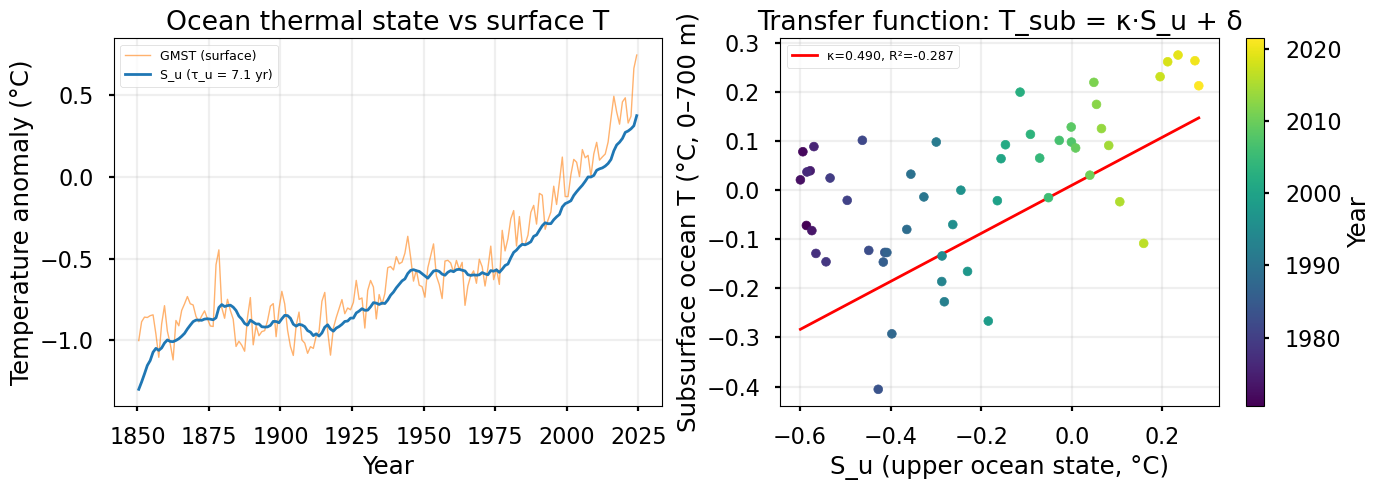

In [5]:
if REFIT:
    # ── Ocean state S_u(t) vs surface T ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: S_u vs T time series
    ax = axes[0]
    t_ann_Su = unique_yrs + 0.5
    Su_ann = np.interp(t_ann_Su, temp_time_monthly, result_phys.S_u_mean)
    ax.plot(t_ann_Su, T_annual, 'C1-', lw=1, alpha=0.6, label='GMST (surface)')
    ax.plot(t_ann_Su, Su_ann, 'C0-', lw=2, label=f'S_u (τ_u = {tau_u_phys:.1f} yr)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Temperature anomaly (°C)')
    ax.set_title('Ocean thermal state vs surface T')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    # Panel B: Transfer function S_u → T_subsurface
    ax = axes[1]
    # Annualise EN4 for comparison
    en4_yr_int = np.floor(en4_global_time).astype(int)
    en4_unique = np.unique(en4_yr_int)
    en4_T_ann = np.array([en4_global_temp[en4_yr_int == y].mean() for y in en4_unique])
    en4_years_ann = en4_unique + 0.5
    # S_u at EN4 years
    Su_at_en4 = np.interp(en4_years_ann, temp_time_monthly, result_phys.S_u_mean)
    ax.scatter(Su_at_en4, en4_T_ann, c=en4_years_ann, cmap='viridis', s=40, zorder=3)
    Su_range = np.array([Su_at_en4.min(), Su_at_en4.max()])
    ax.plot(Su_range,
            ocean_transfer['kappa'] * Su_range + ocean_transfer['delta'],
            'r-', lw=2, label=f'κ={ocean_transfer["kappa"]:.3f}, '
            f'R²={ocean_transfer["r2"]:.3f}')
    ax.set_xlabel('S_u (upper ocean state, °C)')
    ax.set_ylabel('Subsurface ocean T (°C, 0–700 m)')
    ax.set_title('Transfer function: T_sub = κ·S_u + δ')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    cb = fig.colorbar(ax.collections[0], ax=ax)
    cb.set_label('Year')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_stage1b_ocean_state.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('REFIT=False — skipping (loaded from HDF5)')


## 3. Diagnostics & Validation

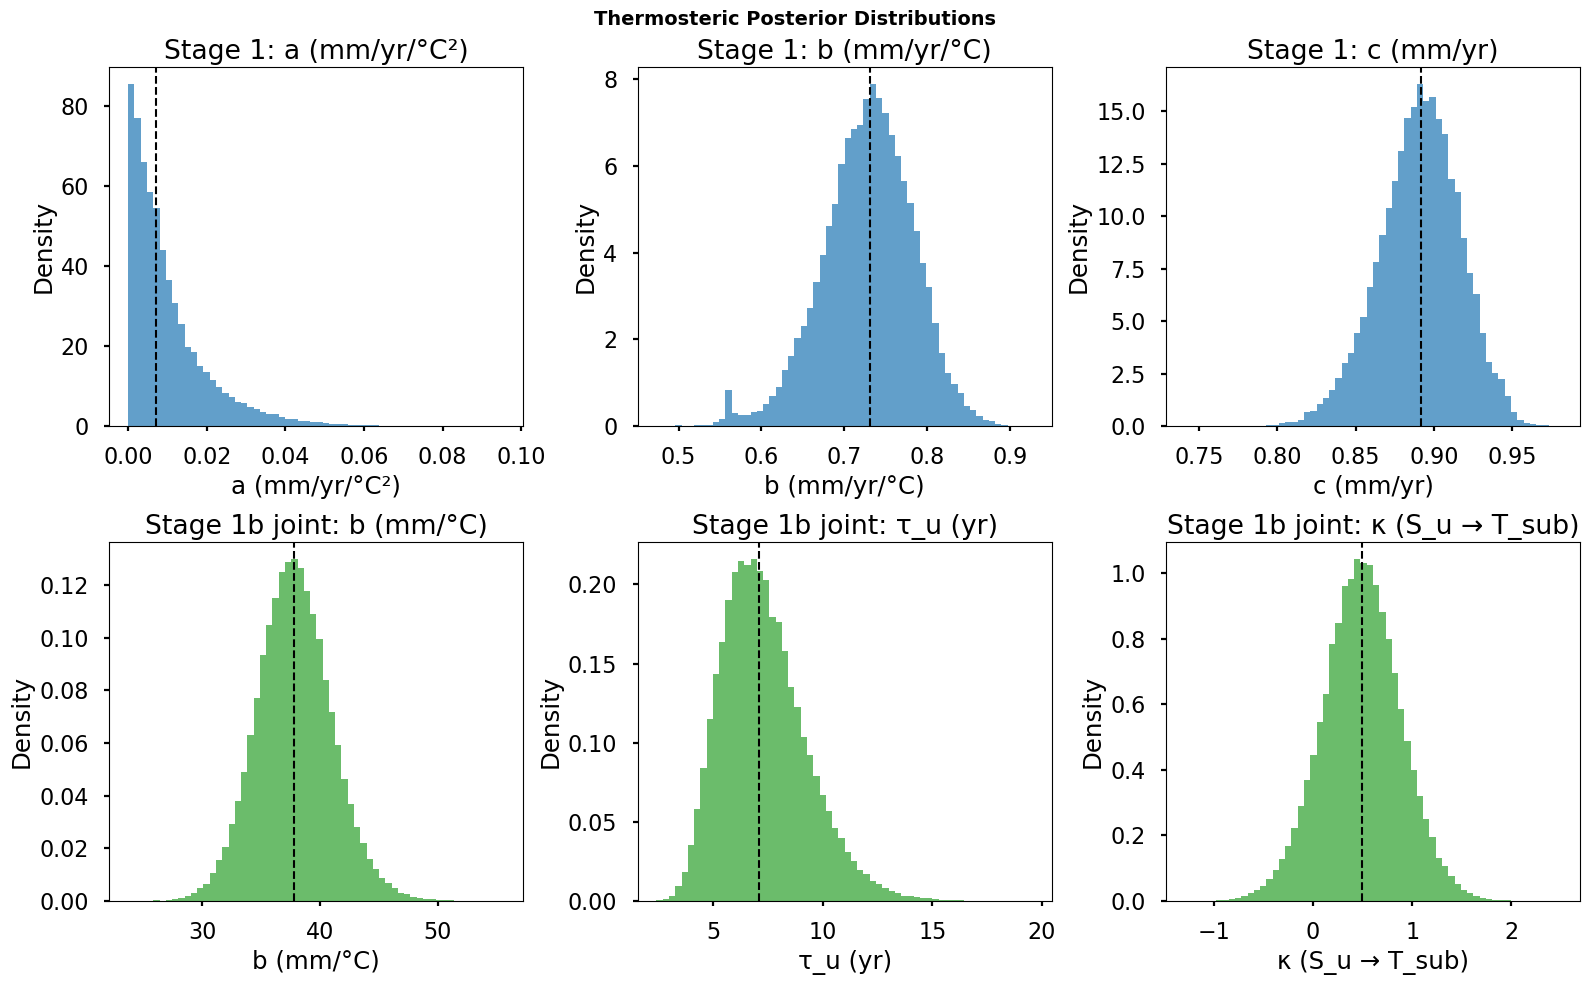

In [6]:
if REFIT:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # Row 1: Stage 1 quadratic posteriors (Frederikse, for comparison)
    ps = result_thermo.posterior_samples
    for i, (ax, label, scale) in enumerate(zip(
        axes[0, :3],
        ['a (mm/yr/°C²)', 'b (mm/yr/°C)', 'c (mm/yr)'],
        [M_TO_MM, M_TO_MM, M_TO_MM],
    )):
        ax.hist(ps[:, i] * scale, bins=60, density=True, alpha=0.7, color='C0')
        ax.axvline(np.median(ps[:, i]) * scale, color='k', ls='--', lw=1.5)
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
        ax.set_title(f'Stage 1: {label}')

    # Row 2: Physical 1L joint model posteriors (b, τ_u, κ)
    for i, (ax, vals, label) in enumerate(zip(
        axes[1, :],
        [result_phys.posterior_samples[:, 1] * M_TO_MM,
         result_phys.tau_u_posterior,
         result_phys.kappa_posterior],
        ['b (mm/°C)', 'τ_u (yr)', 'κ (S_u → T_sub)'],
    )):
        ax.hist(vals, bins=60, density=True, alpha=0.7, color='C2')
        ax.axvline(np.median(vals), color='k', ls='--', lw=1.5)
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
        ax.set_title(f'Stage 1b joint: {label}')

    plt.suptitle('Thermosteric Posterior Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_stage1b_posteriors.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('REFIT=False — skipping (loaded from HDF5)')


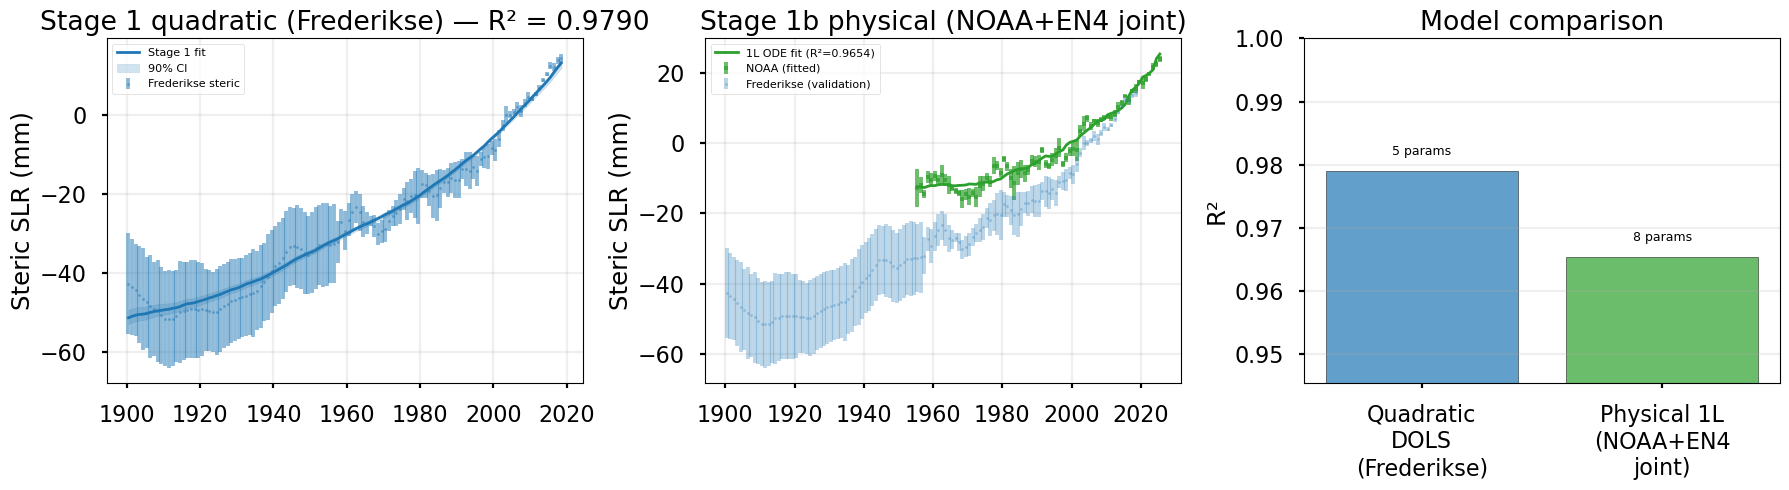

In [7]:
if REFIT:
    from scipy.interpolate import interp1d

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel A: Stage 1 fit (on Frederikse — comparison baseline)
    ax = axes[0]
    H_ens = model_ensemble_draws(result_thermo, design_thermo['I2_obs'],
                                  design_thermo['I1_obs'], design_thermo['I0_obs'])
    p5, p50, p95 = np.percentile(H_ens * M_TO_MM, [5, 50, 95], axis=0)
    ax.errorbar(fred_year, steric_rebase * M_TO_MM, yerr=2 * fred_steric_sigma * M_TO_MM,
                fmt='o', ms=2, color='C0', alpha=0.5, label='Frederikse steric')
    ax.plot(fred_year, p50, 'C0-', lw=2, label='Stage 1 fit')
    ax.fill_between(fred_year, p5, p95, color='C0', alpha=0.2, label='90% CI')
    ax.set_ylabel('Steric SLR (mm)')
    ax.set_title(f'Stage 1 quadratic (Frederikse) — R² = {result_thermo.r2:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Panel B: Stage 1b fit (on NOAA — primary) with Frederikse as validation
    ax = axes[1]
    # NOAA observations (fitted data)
    ax.errorbar(noaa_year, noaa_tsl_m * M_TO_MM, yerr=2 * noaa_tsl_se_m * M_TO_MM,
                fmt='s', ms=3, color='C2', alpha=0.7, label='NOAA (fitted)')
    # Frederikse (validation, not fitted)
    ax.errorbar(fred_year, steric_rebase * M_TO_MM, yerr=2 * fred_steric_sigma * M_TO_MM,
                fmt='o', ms=2, color='C0', alpha=0.3, label='Frederikse (validation)')
    # Stage 1b model at posterior median
    phys_abs_time = result_phys.time + noaa_year[0]
    ax.plot(phys_abs_time, result_phys.H_model_mean * M_TO_MM, 'C2-', lw=2,
            label=f'1L ODE fit (R²={result_phys.r2:.4f})')
    ax.set_ylabel('Steric SLR (mm)')
    ax.set_title(f'Stage 1b physical (NOAA+EN4 joint)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # Panel C: Model comparison — R² and parameter count
    ax = axes[2]
    models = ['Quadratic\nDOLS\n(Frederikse)', 'Physical 1L\n(NOAA+EN4\njoint)']
    r2_vals = [result_thermo.r2, result_phys.r2]
    n_params = [5, 8]  # a,b,c,H0,σ_extra; +τ_u,κ,δ
    colors_bar = ['C0', 'C2']

    bars = ax.bar(models, r2_vals, color=colors_bar, alpha=0.7, edgecolor='k')
    ax.set_ylabel('R²')
    ax.set_title('Model comparison')
    ax.set_ylim(min(r2_vals) - 0.02, 1.0)
    for bar, n_p in zip(bars, n_params):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{n_p} params', ha='center', va='bottom', fontsize=9)
    ax.grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/component_stage1b_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('REFIT=False — skipping (loaded from HDF5)')


## 4. Projections

In [ ]:
# Constants needed by downstream cells regardless of REFIT
SSP_H5_MAP = {
    'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
    'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
}
PROJ_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
if REFIT:
    PROJ_YEARS = np.arange(1950, 2151, dtype=float)

# Load SSP temperatures (needed for plots downstream)
df_hist = pd.read_hdf(H5_PATH, key='projections/temp/Historical')
temp_projections = {}

for ssp_name, h5_key in SSP_H5_MAP.items():
    df_ssp = pd.read_hdf(H5_PATH, key=f'projections/temp/{h5_key}')
    overlap_mask = (df_hist['decimal_year'] >= 1995) & (df_hist['decimal_year'] <= 2005)
    hist_bl = df_hist.loc[overlap_mask, 'temperature'].mean()
    temp_bl = np.mean(temp_monthly[(temp_time_monthly >= 1995) & (temp_time_monthly <= 2005)])
    offset = hist_bl - temp_bl

    hist_part = df_hist[df_hist['decimal_year'] < 2015].copy()
    combined = pd.concat([hist_part, df_ssp]).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    combined['temperature'] = combined['temperature'] - offset
    temp_projections[ssp_name] = combined

if REFIT:
    # ── Project thermosteric (physical 1-layer) ──
    proj_phys_1L = project_thermosteric_ensemble(
        posterior_samples=result_phys.posterior_samples,
        tau_u_samples=result_phys.tau_u_posterior,
        tau_d_samples=None,
        temperature_projections=temp_projections,
        historical_temperature=temp_monthly,
        historical_time=temp_time_monthly,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        n_layers=1,
        seed=100,
    )

    # Build projection dict in standard format (with full MC samples)
    thermo_proj = {}
    for ssp in PROJ_SSPS:
        df_sc = proj_phys_1L['scenarios'][ssp]
        yr = df_sc['decimal_year'].values
        raw_samples = proj_phys_1L['samples'][ssp]

        n_mc = raw_samples.shape[0]
        samples_interp = np.zeros((n_mc, len(PROJ_YEARS)))
        for i in range(n_mc):
            samples_interp[i] = np.interp(PROJ_YEARS, yr, raw_samples[i])

        thermo_proj[ssp] = {
            'samples': samples_interp,
            'median': np.median(samples_interp, axis=0),
            'p5': np.percentile(samples_interp, 5, axis=0),
            'p17': np.percentile(samples_interp, 17, axis=0),
            'p83': np.percentile(samples_interp, 83, axis=0),
            'p95': np.percentile(samples_interp, 95, axis=0),
        }

    # ── Save to HDF5 ──
    save_ocean(
        result_phys=result_phys,
        obs_years=noaa_year,
        obs_H=noaa_tsl_m,
        obs_sigma=noaa_tsl_se_m,
        proj_dict=thermo_proj,
        ocean_transfer=ocean_transfer,
    )
else:
    # Already loaded in REFIT switch cell — just print summary
    pass

# Print 2100 values
for ssp in PROJ_SSPS:
    idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
    med = thermo_proj[ssp]['median'][idx_2100] * M_TO_MM
    lo = thermo_proj[ssp]['p5'][idx_2100] * M_TO_MM
    hi = thermo_proj[ssp]['p95'][idx_2100] * M_TO_MM
    print(f'{ssp} at 2100: {med:.0f} [{lo:.0f}, {hi:.0f}] mm')

/Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/notebooks/component_plotting.py:932: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


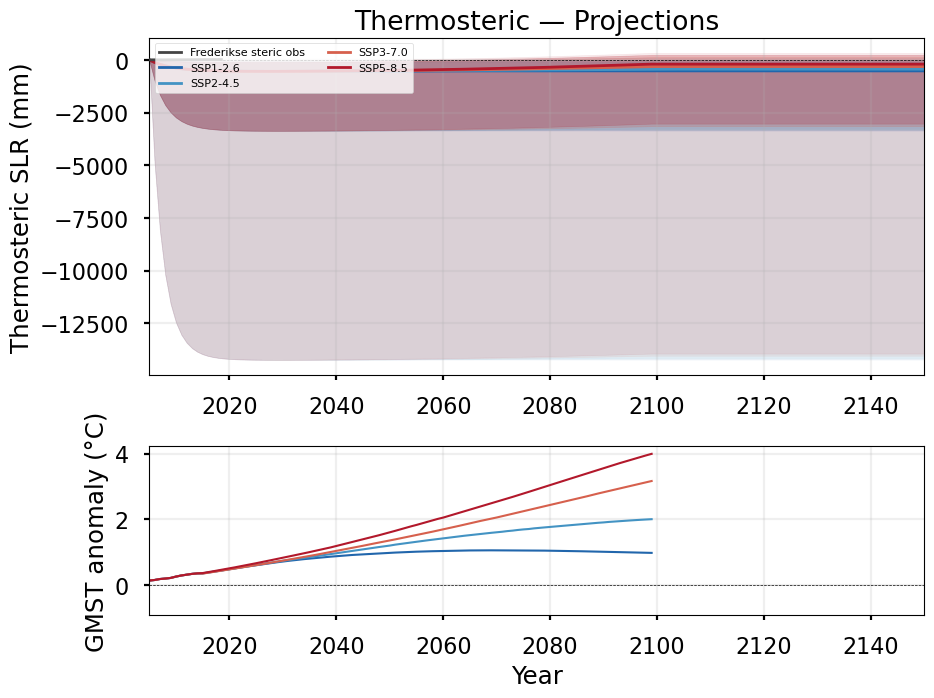

In [9]:
# Build temperature scenario data for lower panel
temp_scenarios = {}
for ssp in PROJ_SSPS:
    df_t = temp_projections[ssp]
    t_ann = df_t.groupby(df_t['decimal_year'].round(0)).agg(
        temperature=('temperature', 'mean')).reset_index()
    temp_scenarios[ssp] = {
        'years': t_ann['decimal_year'].values,
        'temperature': t_ann['temperature'].values,
    }

plot_component_projection_twopanel(
    comp_proj=thermo_proj,
    proj_years=PROJ_YEARS,
    component_name='Thermosteric',
    temperature_scenarios=temp_scenarios,
    temp_label='GMST anomaly (°C)',
    ssps=PROJ_SSPS,
    obs_years=fred_year,
    obs_vals=steric_rebase,
    obs_sigma=fred_steric_sigma,
    obs_label='Frederikse steric obs',
    save_path=f'{FIG_DIR}/component_ocean_twopanel.png',
)

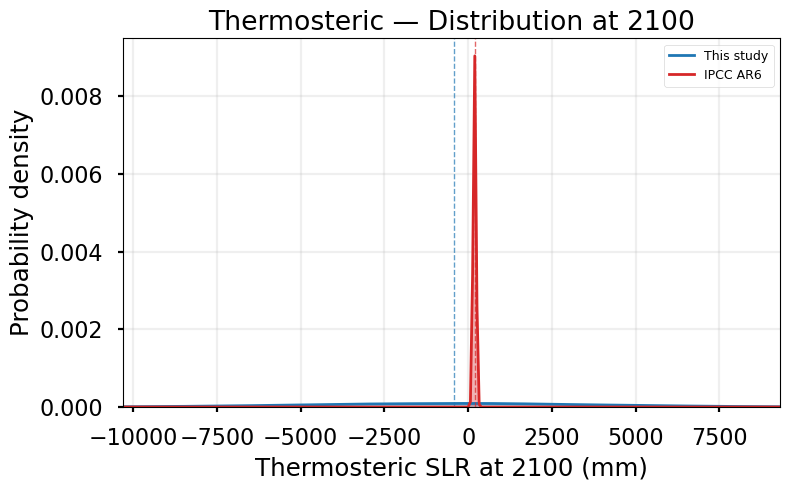

In [10]:
idx_2100 = np.argmin(np.abs(PROJ_YEARS - 2100))
HIST_SSP = 'SSP2-4.5'

# Our samples (reconstruct from summary stats for now)
rng_hist = np.random.default_rng(99)
our_med = thermo_proj[HIST_SSP]['median'][idx_2100]
our_sigma = (thermo_proj[HIST_SSP]['p95'][idx_2100] - thermo_proj[HIST_SSP]['p5'][idx_2100]) / (2 * 1.645)
our_samples = rng_hist.normal(our_med, our_sigma, 10000) * M_TO_MM

# IPCC
ipcc_conf = 'medium_confidence'
SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245', 'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}
ipcc_data = read_ipcc_component_nc(CONF_BASE, ipcc_conf, SSP_CODE[HIST_SSP], 'oceandynamics')
ipcc_samples = np.array([])
if ipcc_data is not None:
    ipcc_ex = ipcc_extract(ipcc_data)
    yr_idx = np.argmin(np.abs(ipcc_ex['years'] - 2100))
    ipcc_med = ipcc_ex['q50'][yr_idx]
    ipcc_sig = (ipcc_ex['q95'][yr_idx] - ipcc_ex['q05'][yr_idx]) / (2 * 1.645)
    ipcc_samples = rng_hist.normal(ipcc_med, ipcc_sig, 10000)

sample_sets = [our_samples]
labels = ['This study']
colors = ['tab:blue']
if len(ipcc_samples) > 0:
    sample_sets.append(ipcc_samples)
    labels.append('IPCC AR6')
    colors.append('tab:red')

plot_component_histogram(
    sample_sets=sample_sets,
    labels=labels,
    colors=colors,
    component_name='Thermosteric',
    year=2100,
    save_path=f'{FIG_DIR}/component_ocean_histogram_2100.png',
)

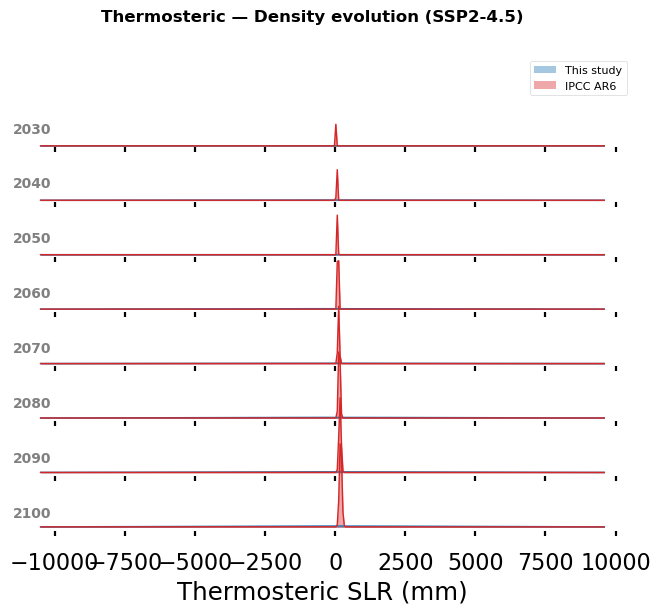

In [11]:
RIDGE_YEARS = list(range(2030, 2110, 10))
RIDGE_SSP = 'SSP2-4.5'
rng_ridge = np.random.default_rng(202)

samples_by_year = {}
for yr in RIDGE_YEARS:
    idx_yr = np.argmin(np.abs(PROJ_YEARS - yr))
    our_med_yr = thermo_proj[RIDGE_SSP]['median'][idx_yr]
    our_sig_yr = (thermo_proj[RIDGE_SSP]['p95'][idx_yr] - thermo_proj[RIDGE_SSP]['p5'][idx_yr]) / (2 * 1.645)
    our_s = rng_ridge.normal(our_med_yr, our_sig_yr, 50000) * M_TO_MM

    year_dict = {'This study': our_s}
    if ipcc_data is not None:
        yr_idx_ipcc = np.argmin(np.abs(ipcc_ex['years'] - yr))
        if np.abs(ipcc_ex['years'][yr_idx_ipcc] - yr) < 5:
            ipcc_med_yr = ipcc_ex['q50'][yr_idx_ipcc]
            ipcc_sig_yr = (ipcc_ex['q95'][yr_idx_ipcc] - ipcc_ex['q05'][yr_idx_ipcc]) / (2 * 1.645)
            year_dict['IPCC AR6'] = rng_ridge.normal(ipcc_med_yr, ipcc_sig_yr, 50000)
    samples_by_year[yr] = year_dict

plot_component_ridge(
    samples_by_year=samples_by_year,
    component_name='Thermosteric',
    ssp_label=RIDGE_SSP,
    source_colors={'This study': 'tab:blue', 'IPCC AR6': 'tab:red'},
    save_path=f'{FIG_DIR}/component_ocean_ridge.png',
)

## 5. IPCC Comparison & Hindcast

In [12]:
# ── Fit ODE to IPCC ocean dynamics median ──
from scipy.optimize import minimize as sp_minimize

SSP_CODE = {'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
            'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585'}

def fit_ode_to_ipcc(years_target, slc_mm, T_monthly, t_monthly, p0=None):
    """Fit single-layer ODE to a smooth IPCC trajectory."""
    slc_m = slc_mm / M_TO_MM
    def forward(theta):
        a, b, c, log_tau, H0 = theta
        tau = np.exp(log_tau)
        S_u, _ = solve_twolayer_ode(T_monthly, t_monthly, tau, np.inf)
        S_u_yr = np.interp(years_target, t_monthly, S_u)
        t_rel = years_target - years_target[0]
        return a * S_u_yr**2 + b * S_u_yr + c * t_rel + H0
    def cost(theta):
        return np.sum((forward(theta) - slc_m)**2)
    if p0 is None:
        p0 = [0.01, 0.05, 0.0003, np.log(10.0), 0.0]
    res = sp_minimize(cost, p0, method='Nelder-Mead',
                      options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-15})
    H_fit = forward(res.x)
    ss_res = np.sum((H_fit - slc_m)**2)
    ss_tot = np.sum((slc_m - np.mean(slc_m))**2)
    return {'a': res.x[0], 'b': res.x[1], 'c': res.x[2],
            'tau_u': np.exp(res.x[3]), 'H0': res.x[4],
            'r2': 1 - ss_res/ss_tot, 'H_fit_m': H_fit, 'forward': forward}

# Build monthly T scenarios and fit
thermo_ipcc_fits = {}
for ssp in PROJ_SSPS:
    ipcc_comp = read_ipcc_component_nc(CONF_BASE, 'medium_confidence',
                                        SSP_CODE[ssp], 'oceandynamics')
    if ipcc_comp is None:
        continue
    ex = ipcc_extract(ipcc_comp)
    # Build monthly T for this SSP
    df_t = temp_projections[ssp]
    t_mon = df_t['decimal_year'].values
    T_mon = df_t['temperature'].values
    # Splice historical
    hist_mask = temp_time_monthly < t_mon[0]
    t_full = np.concatenate([temp_time_monthly[hist_mask], t_mon])
    T_full = np.concatenate([temp_monthly[hist_mask], T_mon])

    fit = fit_ode_to_ipcc(ex['years'], ex['q50'], T_full, t_full)
    thermo_ipcc_fits[ssp] = fit
    print(f'{ssp}: b={fit["b"]*M_TO_MM:.3f} mm/°C, τ_u={fit["tau_u"]:.1f} yr, R²={fit["r2"]:.6f}')

SSP1-2.6: b=0.000 mm/°C, τ_u=0.0 yr, R²=-28.000000
SSP2-4.5: b=-0.000 mm/°C, τ_u=0.0 yr, R²=-28.000000
SSP3-7.0: b=0.000 mm/°C, τ_u=0.0 yr, R²=-28.000000
SSP5-8.5: b=0.000 mm/°C, τ_u=0.0 yr, R²=-28.000000


NameError: name 'HAS_NOAA' is not defined

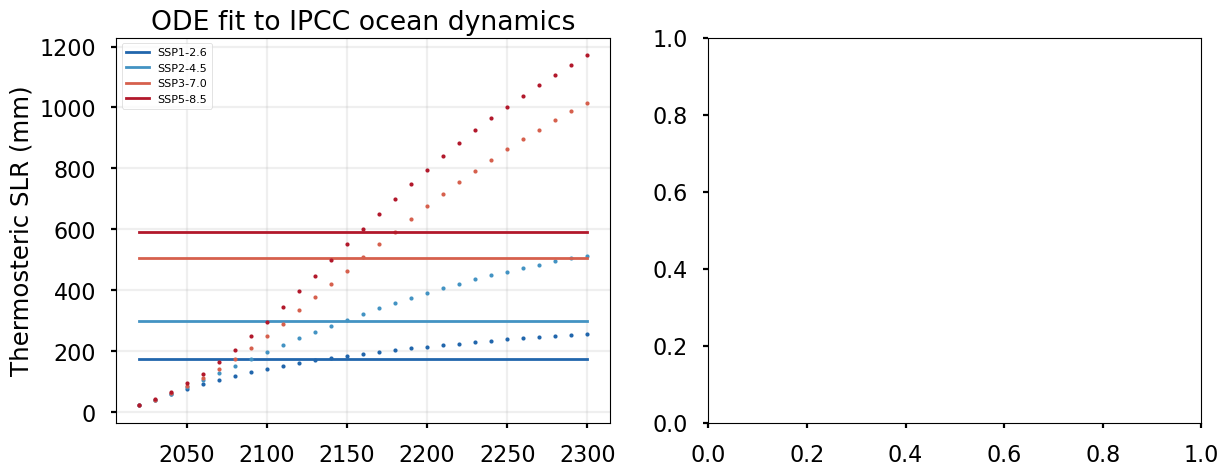

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: IPCC fits
ax = axes[0]
for ssp, fit in thermo_ipcc_fits.items():
    ipcc_comp = read_ipcc_component_nc(CONF_BASE, 'medium_confidence',
                                        SSP_CODE[ssp], 'oceandynamics')
    ex = ipcc_extract(ipcc_comp)
    color = SSP_COLORS.get(ssp, 'gray')
    ax.plot(ex['years'], ex['q50'], 'o', ms=3, color=color)
    ax.plot(ex['years'], fit['H_fit_m'] * M_TO_MM, '-', lw=2, color=color, label=f'{ssp}')
ax.set_ylabel('Thermosteric SLR (mm)')
ax.set_title('ODE fit to IPCC ocean dynamics')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Panel B: Hindcast vs NOAA
ax = axes[1]
if HAS_NOAA:
    ax.plot(noaa_year, noaa_tsl_rebase * M_TO_MM, 'k-', lw=2, label='NOAA observed')
    for ssp, fit in thermo_ipcc_fits.items():
        S_u_obs, _ = solve_twolayer_ode(temp_monthly, temp_time_monthly, fit['tau_u'], np.inf)
        S_u_ann = np.interp(noaa_year, temp_time_monthly, S_u_obs)
        t_rel = noaa_year - noaa_year[0]
        H_hind = fit['a'] * S_u_ann**2 + fit['b'] * S_u_ann + fit['c'] * t_rel + fit['H0']
        bl = np.argmin(np.abs(noaa_year - BASELINE_YEAR))
        H_hind -= H_hind[bl]
        color = SSP_COLORS.get(ssp, 'gray')
        ax.plot(noaa_year, H_hind * M_TO_MM, '--', lw=1.5, color=color, label=f'{ssp} hindcast')
    ax.set_ylabel('Thermosteric SLR (mm, 2005 baseline)')
    ax.set_title('IPCC sensitivity hindcast vs NOAA')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)
else:
    ax.text(0.5, 0.5, 'NOAA data not available', transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/component_ocean_ipcc_hindcast.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Appendix: Sensitivity analyses

These do **not** feed into the primary projections or downstream components.

In [ ]:
from component_analysis import apply_sigma_taper, restrict_and_fit

# Taper sensitivity for thermosteric
F_MAX_VALUES = [1, 2, 3]
TAPER_REF = 2005
OBS_WINDOW = (1957, 2018)

taper_results_thermo = {}
for f_max in F_MAX_VALUES:
    mask = (fred_year >= OBS_WINDOW[0]) & (fred_year <= OBS_WINDOW[1])
    yrs_r = fred_year[mask]
    H_r = steric_rebase[mask].copy()
    sig_r = fred_steric_sigma[mask].copy()
    sig_tapered = apply_sigma_taper(sig_r, yrs_r, TAPER_REF, f_max)

    design_r = build_level_design_vectors(
        temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
        obs_times=yrs_r)

    res_q = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_tapered,
        I2_obs=design_r['I2_obs'], I1_obs=design_r['I1_obs'],
        I0_obs=design_r['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=200 + f_max*100,
        prior_scale_a=PRIOR_SCALE_A_THERMO, prior_scale_b=PRIOR_SCALE_B_THERMO,
        prior_c_mean=PRIOR_C_MEAN_THERMO, prior_c_sigma=PRIOR_C_SIGMA_THERMO,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
        prior_H0_sigma=PRIOR_H0_SIGMA_THERMO)
    res_l = fit_bayesian_level(
        H_obs=H_r, sigma_obs=sig_tapered,
        I2_obs=np.zeros_like(design_r['I2_obs']),
        I1_obs=design_r['I1_obs'], I0_obs=design_r['I0_obs'],
        n_samples=4000, n_walkers=32, n_burnin=2000, thin=2,
        seed=300 + f_max*100,
        prior_scale_a=PRIOR_SCALE_A_THERMO, prior_scale_b=PRIOR_SCALE_B_THERMO,
        prior_c_mean=PRIOR_C_MEAN_THERMO, prior_c_sigma=PRIOR_C_SIGMA_THERMO,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_THERMO,
        prior_H0_sigma=PRIOR_H0_SIGMA_THERMO)

    taper_results_thermo[f_max] = {'quad': res_q, 'linear': res_l}

    n = len(yrs_r)
    a_s = res_q.posterior_samples[:, 0] * M_TO_MM
    rss_q = np.sum(res_q.residuals**2)
    rss_l = np.sum(res_l.residuals**2)
    bic_q = n * np.log(rss_q / n) + 5 * np.log(n)
    bic_l = n * np.log(rss_l / n) + 4 * np.log(n)
    print(f'f_max={f_max}: a={np.median(a_s):.4f} mm/yr/°C², '
          f'R²_q={res_q.r2:.4f}, R²_l={res_l.r2:.4f}, ΔBIC={bic_l - bic_q:+.1f}')

### 7b. Two-layer ocean sensitivity

Exploratory extension adding a deep-ocean layer with relaxation τ_d. Not used
for primary projections — single-layer is sufficient (τ_d unresolvable in the
~70-year NOAA window; marginal R² improvement).

In [ ]:
# ── Two-layer ODE sensitivity (not used for projections) ──
result_phys_2L = fit_bayesian_thermosteric(
    H_obs=noaa_tsl_m,
    sigma_obs=noaa_tsl_se_m,
    T_monthly=temp_monthly,
    time_monthly=temp_time_monthly,
    obs_times=noaa_year,
    n_layers=2,
    prior_scale_a=0.22,
    prior_scale_b=0.15,
    prior_c_mean=0.0003,
    prior_c_sigma=0.0005,
    prior_sigma_extra_scale=0.003,
    prior_H0_sigma=0.010,
    prior_scale_b_d=0.10,
    # Joint calibration
    T_ocean_obs=en4_global_temp,
    sigma_ocean_obs=en4_global_sigma,
    time_ocean_obs=en4_global_time,
    prior_kappa_mean=0.5,
    prior_kappa_sigma=0.5,
    prior_delta_sigma=0.3,
    prior_sigma_ocean_scale=0.1,
    # MCMC
    n_samples=15000,
    n_walkers=128,
    n_burnin=6000,
    thin=3,
    seed=43,
)

tau_u_2L = np.median(result_phys_2L.tau_u_posterior)
tau_d_2L = np.median(result_phys_2L.tau_d_posterior)

print(f'Two-layer physical model (sensitivity):')
print(f'  τ_u = {tau_u_2L:.1f} yr, τ_d = {tau_d_2L:.1f} yr')
print(f'  R² (steric) = {result_phys_2L.r2:.4f}')
print(f'  ΔR² vs 1-layer = {result_phys_2L.r2 - result_phys.r2:.6f}')

check_convergence(result_phys_2L.trace, quiet=False)